# Trabajo Práctico 5 / TS5 | Romero Marchione, Luz | 29/9/26

En este trabajo se estimará la densidad espectral de potencia de distintas señales biomédicas y de audio, seleccionando un método de estimación adecuado y analizando sus parámetros. A partir de las PSD obtenidas se estimará el ancho de banda de cada señal y se compararán los resultados.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Fundamentos teóricos</h2>
</div>

### Densidad espectral de potencia

La densidad espectral de potencia (PSD) describe cómo se distribuye la potencia de una señal en función de la frecuencia. Para un proceso estacionario se define como la transformada de Fourier de su función de autocorrelación:

$$
S_{xx}(f)=\mathcal{F}\{r_{xx}[m]\}
$$

El área bajo la PSD representa la potencia de la señal contenida en un determinado intervalo de frecuencias. Como en la práctica se dispone de una cantidad finita de muestras, la PSD debe ser estimada.

### Estimadores espectrales

#### Periodograma

El periodograma estima la PSD a partir del módulo cuadrado de la DFT de la señal. Al utilizar toda la señal en una única estimación puede brindar una buena resolución espectral, pero presenta una varianza elevada. Además, aunque su sesgo disminuye al aumentar la cantidad de muestras, su varianza no tiende a cero, por lo que no es un estimador consistente.

#### Método de Welch

El método de Welch reduce la varianza mediante el promedio de varios periodogramas. Para ello, la señal de $N$ muestras se divide en $M$ segmentos de longitud $L$, generalmente solapados, se aplica una ventana a cada segmento y se calcula su periodograma. La estimación final se obtiene como:

$$
\hat{S}_{xx}(f)=\frac{1}{M}\sum_{m=0}^{M-1}P_m(f)
$$

En este trabajo se utilizará un solapamiento del 50 %, por lo que segmentos consecutivos comparten $L/2$ muestras. Para controlar de manera sencilla la longitud de los segmentos se definirá $K=N/L$. Al mantener $N$ constante, aumentar $K$ implica disminuir $L$ y generar una mayor cantidad de segmentos para promediar. Con un solapamiento del 50 %, la cantidad real de segmentos $M$ aumenta aproximadamente junto con $K$ ($M\approx2K-1$).

De esta manera, $K$ funciona como el parámetro utilizado para controlar el compromiso entre resolución y varianza: valores pequeños de $K$ producen segmentos más largos y mayor resolución, mientras que valores mayores generan más promedios y una estimación de menor varianza.

Para implementar el método se utilizará `scipy.signal.welch`. Los principales parámetros utilizados serán:

- `fs`: frecuencia de muestreo.
- `nperseg`: longitud $L$ de cada segmento, calculada como $N/K$.
- `noverlap`: cantidad de muestras compartidas entre segmentos, fijada en $L/2$.
- `window`: se utilizará una ventana Hann, que reduce el leakage espectral y presenta un compromiso adecuado entre ancho del lóbulo principal y lóbulos laterales. En este análisis no se busca separar componentes extremadamente próximas, por lo que no resulta necesario priorizar una ventana con un lóbulo principal especialmente angosto.
- `nfft`: se fijará igual a $N$ para obtener una grilla frecuencial más densa y facilitar la visualización e integración de la PSD. Este zero-padding no mejora la resolución espectral real.
- `scaling='density'`: permite obtener la densidad espectral de potencia.

### Varianza, resolución y sesgo

La resolución espectral indica la capacidad de distinguir componentes frecuenciales próximas, mientras que la varianza representa cuánto puede fluctuar la estimación entre distintas realizaciones. El sesgo mide la diferencia sistemática entre el valor esperado del estimador y la PSD verdadera, $b(f)=E\{\hat S_{xx}(f)\}-S_{xx}(f)$.

En Welch existe un compromiso directo entre resolución y varianza. Al aumentar $L$ mejora la resolución, pero disminuye la cantidad de segmentos disponibles para promediar. Al disminuir $L$ ocurre lo contrario. Aproximadamente:

$$
\mathrm{var}\{\hat{S}_{xx}\}\propto\frac{1}{M}
$$

Por lo tanto, al aumentar $K$ aumenta $M$ y disminuye la varianza, a costa de una menor resolución espectral.

### Método de Blackman-Tukey

Blackman-Tukey constituye otra alternativa no paramétrica para estimar la PSD. A diferencia de Welch, parte de una estimación de la función de autocorrelación, que posteriormente se ventana y transforma al dominio de la frecuencia. Este método no será desarrollado en el trabajo, ya que se optó por utilizar Welch.

### Criterio para la estimación del ancho de banda

El ancho de banda se estimará utilizando el área bajo la PSD y considerando como banda útil aquella que contiene el 95 % de la potencia total. El área se calculará numéricamente mediante trapecios, $A_i=(PSD_{i-1}+PSD_i)\Delta f/2$.

Para señales con comportamiento pasa-bajos, se acumulará potencia desde $0$ Hz hasta alcanzar el 95 %. Para señales pasa-banda, se dejará un 2.5 % de la potencia a cada extremo, de manera que el intervalo central contenga el 95 %.

El ancho de banda se calculará finalmente como:

$$
BW=f_{sup}-f_{inf}
$$

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Desarrollo</h2>
</div>

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

A continuación, se verificará sobre la señal de ECG lo explicado en el apartado teórico acerca de las diferencias entre el periodograma y el método de Welch.

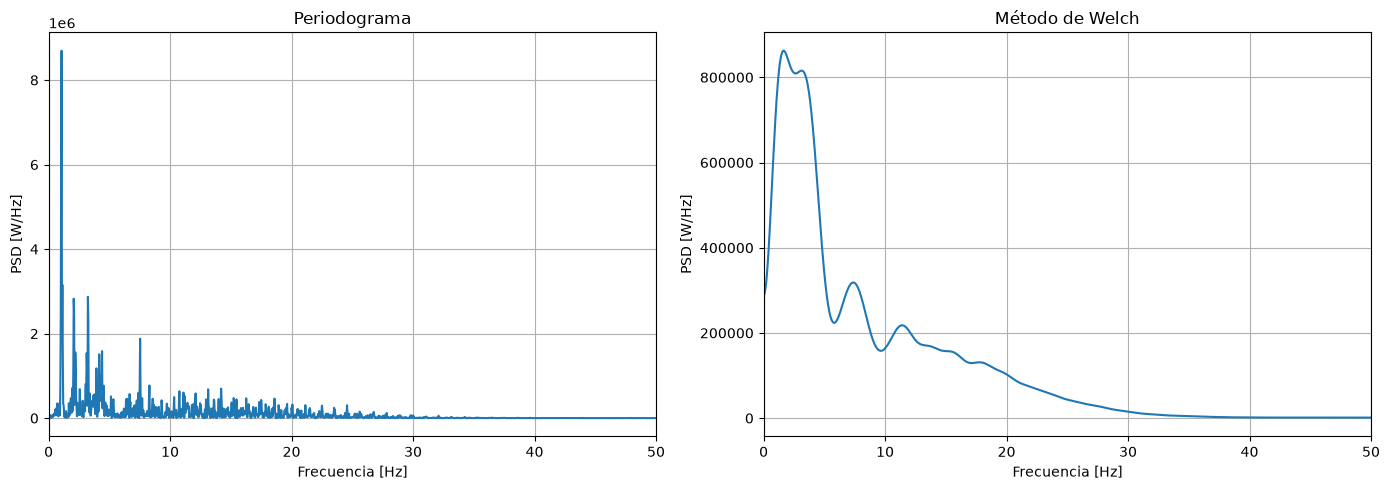

In [62]:
# ECG
fs_ecg = 1000
ecg_one_lead = np.load('ecg_sin_ruido.npy')
N_ecg = len(ecg_one_lead)
# comparación de métodos para el ECG
f_per, pxx_per = sig.periodogram(ecg_one_lead, fs=fs_ecg, window='hann', nfft=N_ecg, scaling='density')

K_ecg = 35
L_ecg = N_ecg // K_ecg
overlap_ecg = L_ecg // 2
f_welch, pxx_welch = sig.welch(ecg_one_lead, fs=fs_ecg, window='hann', nperseg=L_ecg, noverlap=overlap_ecg, nfft=N_ecg, scaling='density')

fig, ax = plt.subplots(1,2,figsize=(14,5))

ax[0].plot(f_per, pxx_per)
ax[0].set_xlim([0,50])
ax[0].set_xlabel('Frecuencia [Hz]')
ax[0].set_ylabel('PSD [W/Hz]')
ax[0].set_title('Periodograma')
ax[0].grid()

ax[1].plot(f_welch, pxx_welch)
ax[1].set_xlim([0,50])
ax[1].set_xlabel('Frecuencia [Hz]')
ax[1].set_ylabel('PSD [W/Hz]')
ax[1].set_title('Método de Welch')
ax[1].grid()

plt.tight_layout()
plt.show()

#### Elección del método de estimación

A modo de comparación, se estimó la PSD del ECG mediante el periodograma y el método de Welch. Como se observa en la figura, el periodograma conserva una mayor resolución espectral, pero presenta una estimación más variable. En cambio, Welch genera una PSD más suavizada debido al promedio de los periodogramas obtenidos a partir de distintos segmentos de la señal.

Como el objetivo del trabajo es estimar la distribución general de potencia y posteriormente determinar el ancho de banda, se seleccionó el método de Welch, priorizando una menor varianza del estimador frente a una resolución espectral mayor a la necesaria.

A continuación se presentan los resultados obtenidos para las cinco señales analizadas: ECG, PPG, audio "La cucaracha", audio "Prueba PSD" y audio "Silbido". Para cada una se mostrará la comparación entre distintos valores de $K$ utilizada para seleccionar el estimador de la DEP y, posteriormente, la estimación de su ancho de banda. Finalmente, se presentará una tabla comparativa con los anchos de banda obtenidos para todas las señales.

#### ECG

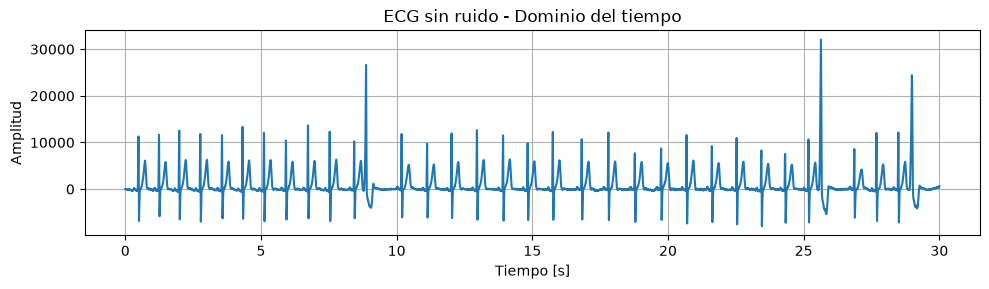

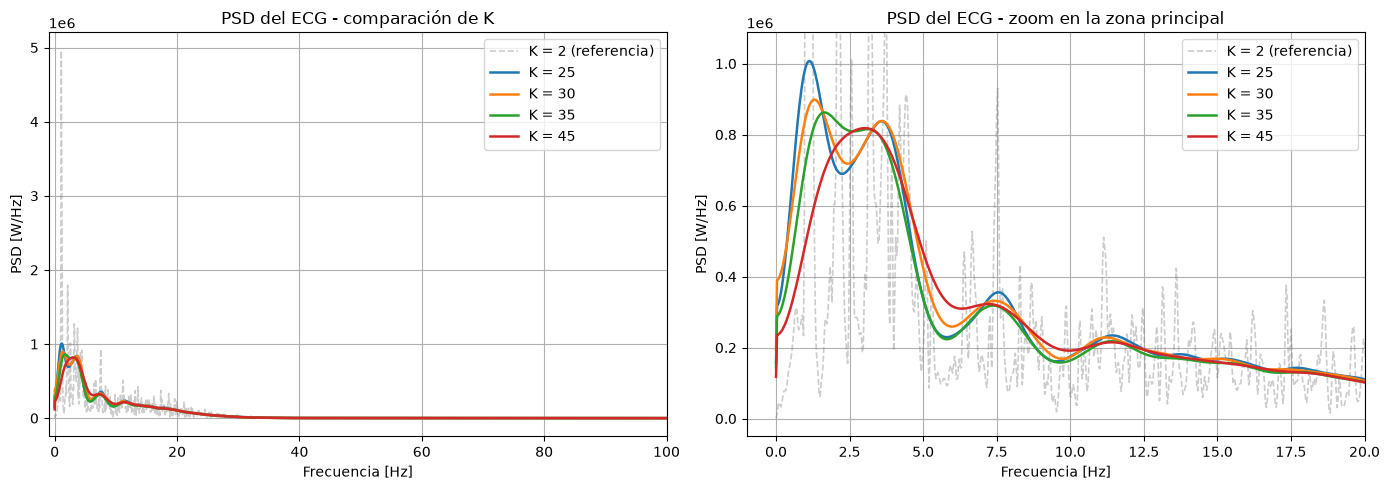

Ancho de banda al 95% = 22.83 Hz


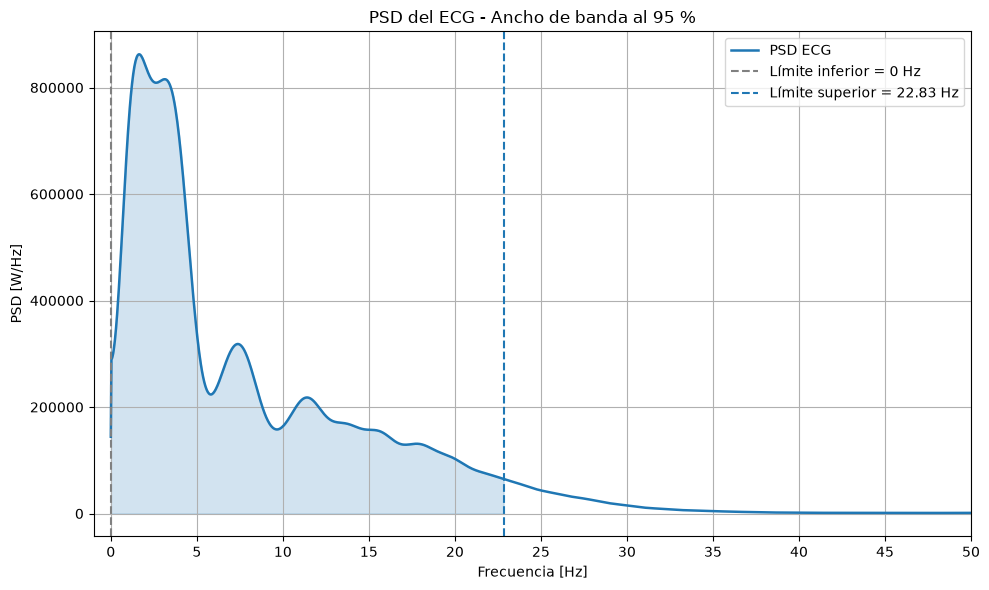

In [63]:
# ECG
fs_ecg = 1000
ecg_one_lead = np.load('ecg_sin_ruido.npy')
N_ecg = len(ecg_one_lead)

# señal en el tiempo
t_ecg = np.arange(N_ecg) / fs_ecg

plt.figure(figsize=(10,3))
plt.plot(t_ecg, ecg_one_lead)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('ECG sin ruido - Dominio del tiempo')
plt.grid()
plt.tight_layout()
plt.show()

# comparo distintos valores de K
K_ref = 2
K_vec = [25, 30, 35, 45]

L_ref = N_ecg // K_ref
overlap_ref = L_ref // 2
f_ref, pxx_ref = sig.welch(ecg_one_lead, fs=fs_ecg, window='hann', nperseg=L_ref, noverlap=overlap_ref, nfft=N_ecg, scaling='density')

fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')
ax[1].plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')

pxx_max = 0
for K in K_vec:
    L = N_ecg // K
    overlap = L // 2
    f, pxx = sig.welch(ecg_one_lead, fs=fs_ecg, window='hann', nperseg=L, noverlap=overlap, nfft=N_ecg, scaling='density')
    ax[0].plot(f, pxx, linewidth=1.8, label=f'K = {K}')
    ax[1].plot(f, pxx, linewidth=1.8, label=f'K = {K}')
    pxx_max = max(pxx_max, np.max(pxx))

ax[0].set_xlim([-1,100])
ax[1].set_xlim([-1,20])
ax[1].set_ylim([-0.05*pxx_max,1.08*pxx_max])

for a in ax:
    a.set_xlabel('Frecuencia [Hz]')
    a.set_ylabel('PSD [W/Hz]')
    a.grid()
    a.legend()

ax[0].set_title('PSD del ECG - comparación de K')
ax[1].set_title('PSD del ECG - zoom en la zona principal')
plt.tight_layout()
plt.show()

# PSD final con K=35
K_ecg = 35
L_ecg = N_ecg // K_ecg
overlap_ecg = L_ecg // 2
f_ecg, pxx_ecg = sig.welch(ecg_one_lead, fs=fs_ecg, window='hann', nperseg=L_ecg, noverlap=overlap_ecg, nfft=N_ecg, scaling='density')

df = f_ecg[1] - f_ecg[0]

# potencia total
potencia_total = 0
for i in range(1, len(f_ecg)):
    area = (pxx_ecg[i-1] + pxx_ecg[i]) / 2 * df
    potencia_total += area

# frecuencia que acumula el 95% de la potencia
potencia_95 = 0.95 * potencia_total
potencia_acumulada = 0

for i in range(1, len(f_ecg)):
    area = (pxx_ecg[i-1] + pxx_ecg[i]) / 2 * df
    potencia_acumulada += area
    if potencia_acumulada >= potencia_95:
        f_95 = f_ecg[i]
        break

print(f'Ancho de banda al 95% = {f_95:.2f} Hz')

plt.figure(figsize=(10,6))
plt.plot(f_ecg, pxx_ecg, linewidth=1.8, label='PSD ECG')
plt.axvline(0, linestyle='--', color='gray', label='Límite inferior = 0 Hz')
plt.axvline(f_95, linestyle='--', color='tab:blue', label=f'Límite superior = {f_95:.2f} Hz')
plt.fill_between(f_ecg, 0, pxx_ecg, where=(f_ecg >= 0) & (f_ecg <= f_95), alpha=0.2, color='tab:blue')
plt.xlim([-1,50])
plt.xticks(np.arange(0,51,5))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD del ECG - Ancho de banda al 95 %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### Elección de K

Tal como se observa en la figura, se compararon los valores $K=25$, $30$, $35$ y $45$. Para $K=25$ se obtiene una mayor resolución espectral, mientras que al aumentar hasta $K=45$ la resolución disminuye.

Como el objetivo es estimar la PSD y no distinguir componentes frecuenciales muy próximas, se seleccionó $K=35$. En la figura ampliada se observa que este valor conserva adecuadamente tanto el pico principal como las estructuras secundarias relevantes, logrando un buen compromiso entre resolución y suavizado de la estimación.

#### Ancho de banda del ECG
Como el ECG presenta un comportamiento pasa-bajos, el límite inferior se toma en 0 Hz, por lo que el ancho de banda estimado es $BW=22.83$ Hz.

#### PPG

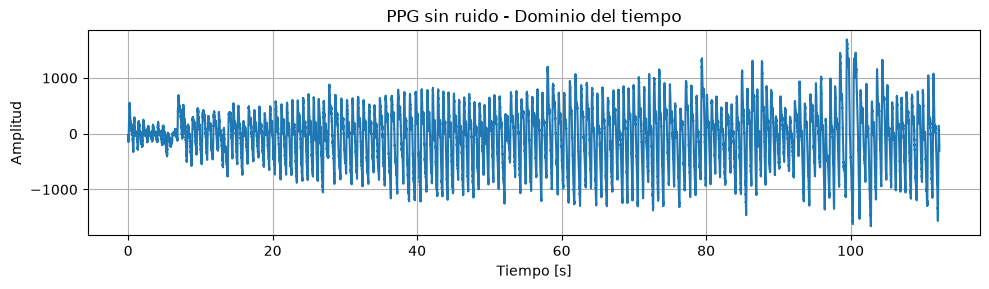

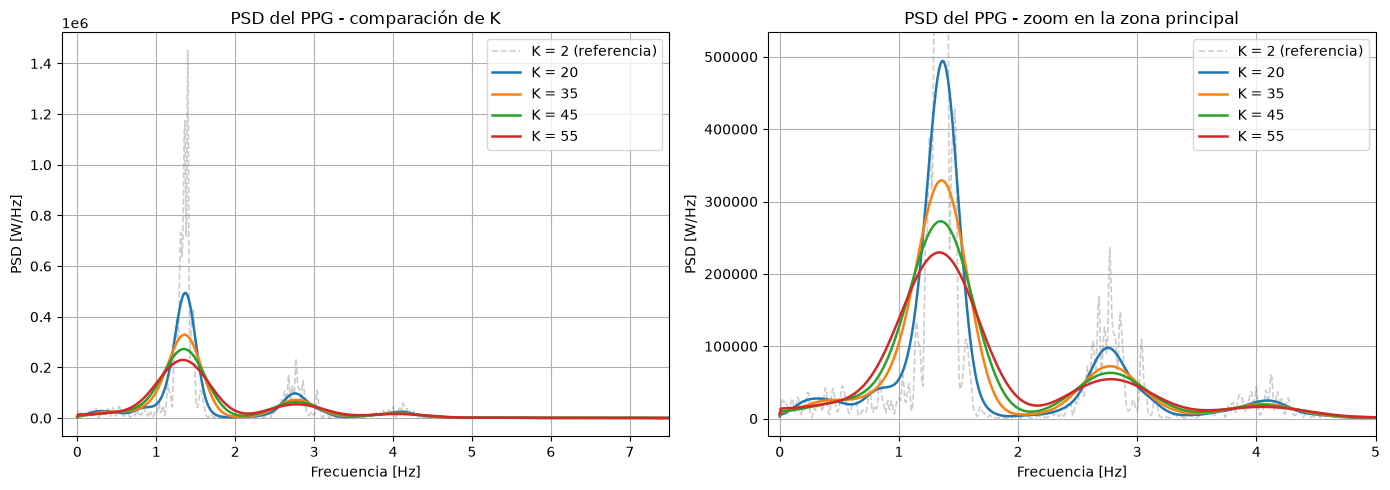

Ancho de banda al 95% = 3.95 Hz


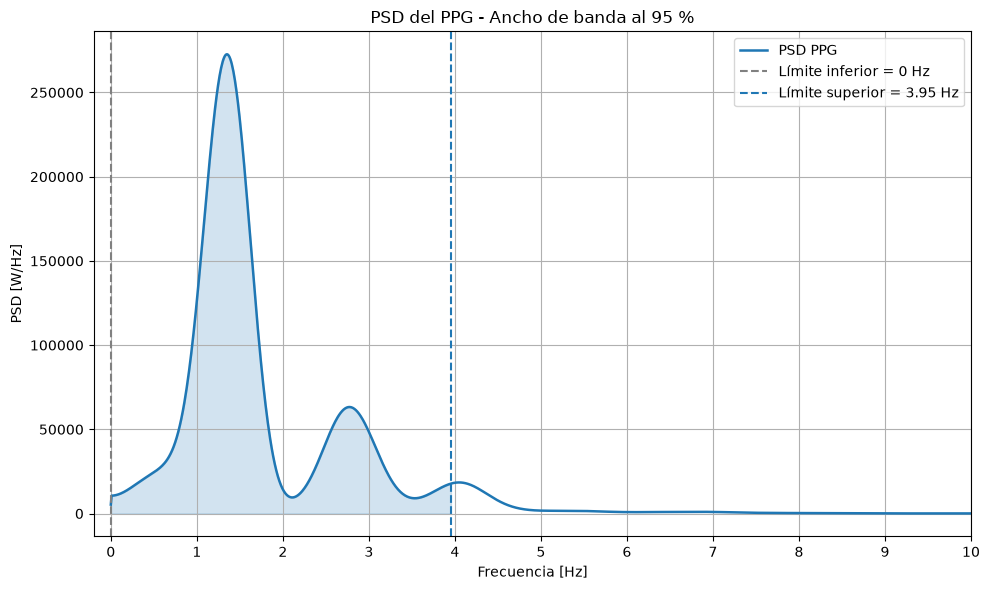

In [50]:
# PPG
fs_ppg = 400
ppg = np.load('ppg_sin_ruido.npy')
N_ppg = len(ppg)

# señal en el tiempo
t_ppg = np.arange(N_ppg) / fs_ppg

plt.figure(figsize=(10,3))
plt.plot(t_ppg, ppg)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('PPG sin ruido - Dominio del tiempo')
plt.grid()
plt.tight_layout()
plt.show()

# comparo distintos valores de K
K_ref = 2
K_vec = [20, 35, 45, 55]

L_ref = N_ppg // K_ref
overlap_ref = L_ref // 2
f_ref, pxx_ref = sig.welch(ppg, fs=fs_ppg, window='hann', nperseg=L_ref, noverlap=overlap_ref, nfft=N_ppg, scaling='density')

fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')
ax[1].plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')

pxx_max = 0
for K in K_vec:
    L = N_ppg // K
    overlap = L // 2
    f, pxx = sig.welch(ppg, fs=fs_ppg, window='hann', nperseg=L, noverlap=overlap, nfft=N_ppg, scaling='density')
    ax[0].plot(f, pxx, linewidth=1.8, label=f'K = {K}')
    ax[1].plot(f, pxx, linewidth=1.8, label=f'K = {K}')
    pxx_max = max(pxx_max, np.max(pxx))

ax[0].set_xlim([-0.2,7.5])
ax[1].set_xlim([-0.1,5])
ax[1].set_ylim([-0.05*pxx_max,1.08*pxx_max])

for a in ax:
    a.set_xlabel('Frecuencia [Hz]')
    a.set_ylabel('PSD [W/Hz]')
    a.grid()
    a.legend()

ax[0].set_title('PSD del PPG - comparación de K')
ax[1].set_title('PSD del PPG - zoom en la zona principal')
plt.tight_layout()
plt.show()

# PSD final con K=45
K_ppg = 45
L_ppg = N_ppg // K_ppg
overlap_ppg = L_ppg // 2
f_ppg, pxx_ppg = sig.welch(ppg, fs=fs_ppg, window='hann', nperseg=L_ppg, noverlap=overlap_ppg, nfft=N_ppg, scaling='density')

df = f_ppg[1] - f_ppg[0]

# potencia total
potencia_total = 0
for i in range(1, len(f_ppg)):
    area = (pxx_ppg[i-1] + pxx_ppg[i]) / 2 * df
    potencia_total += area

# frecuencia que acumula el 95% de la potencia
potencia_95 = 0.95 * potencia_total
potencia_acumulada = 0

for i in range(1, len(f_ppg)):
    area = (pxx_ppg[i-1] + pxx_ppg[i]) / 2 * df
    potencia_acumulada += area
    if potencia_acumulada >= potencia_95:
        f_95 = f_ppg[i]
        break

print(f'Ancho de banda al 95% = {f_95:.2f} Hz')

plt.figure(figsize=(10,6))
plt.plot(f_ppg, pxx_ppg, linewidth=1.8, label='PSD PPG')
plt.axvline(0, linestyle='--', color='gray', label='Límite inferior = 0 Hz')
plt.axvline(f_95, linestyle='--', color='tab:blue', label=f'Límite superior = {f_95:.2f} Hz')
plt.fill_between(f_ppg, 0, pxx_ppg, where=(f_ppg >= 0) & (f_ppg <= f_95), alpha=0.2, color='tab:blue')
plt.xlim([-0.2,10])
plt.xticks(np.arange(0,11,1))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD del PPG - Ancho de banda al 95 %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### Elección de K

Tal como se observa en la figura, se compararon los valores $K=20$, $35$, $45$ y $55$. Para $K=20$ se obtiene una resolución mayor a la necesaria para este análisis, mientras que para $K=55$ comienza a observarse un ensanchamiento apreciable de los lóbulos, indicando una pérdida de resolución.

Por este motivo, la elección se concentró entre $K=35$ y $K=45$. En las figuras ampliadas se observa que ambos valores conservan adecuadamente las componentes principales de la señal, sin una diferencia importante en resolución. Se seleccionó entonces $K=45$, ya que permite realizar una mayor cantidad de promedios y, por lo tanto, reducir la varianza del estimador.

Con el solapamiento del 50 % utilizado, para $K=35$ se obtienen $M=68$ segmentos y para $K=45$, $M=89$. Considerando que la varianza disminuye aproximadamente de forma inversa con la cantidad de promedios:
$
\frac{\mathrm{var}_{45}}{\mathrm{var}_{35}}\approx\frac{68}{89}=0.76
$

por lo que el uso de $K=45$ representa una reducción aproximada del $24\,\%$ en la varianza respecto de $K=35$, sin una pérdida apreciable de la información espectral relevante.

#### Ancho de banda del PPG
Como el PPG presenta un comportamiento pasa-bajos, el límite inferior se toma en 0 Hz, por lo que el ancho de banda estimado es $BW=3.95$ Hz.

#### CUCARACHA

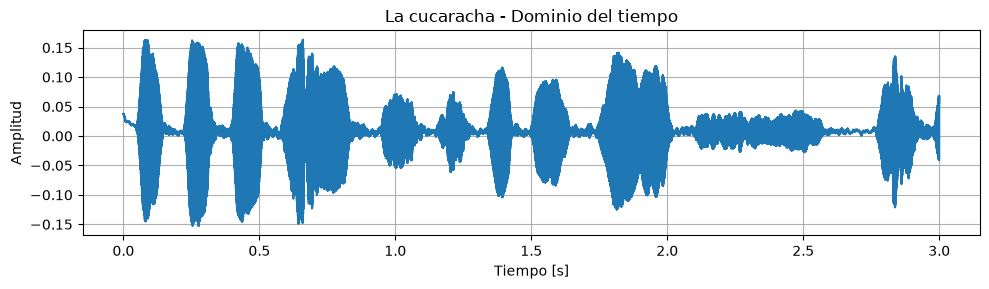

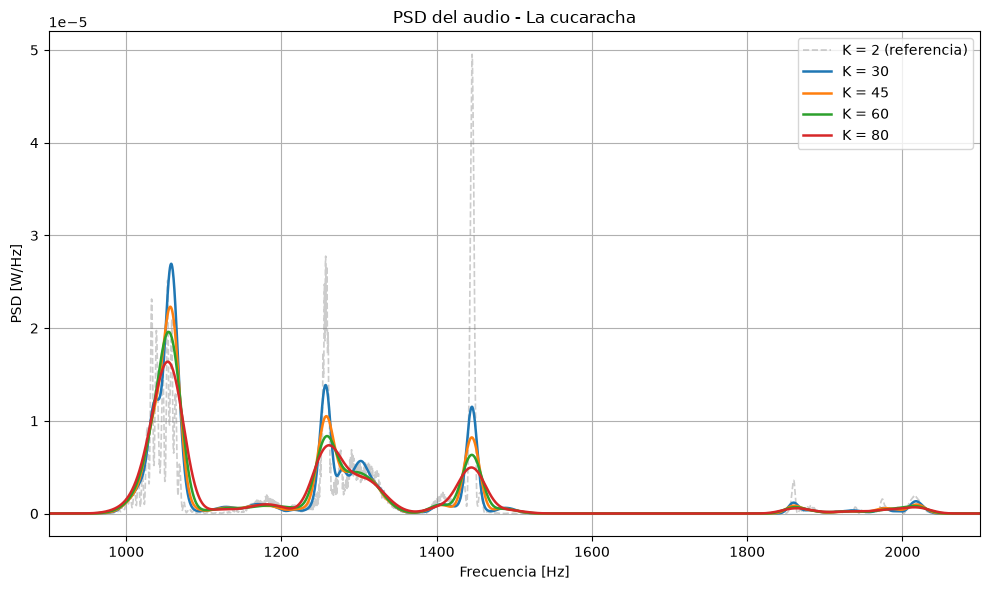

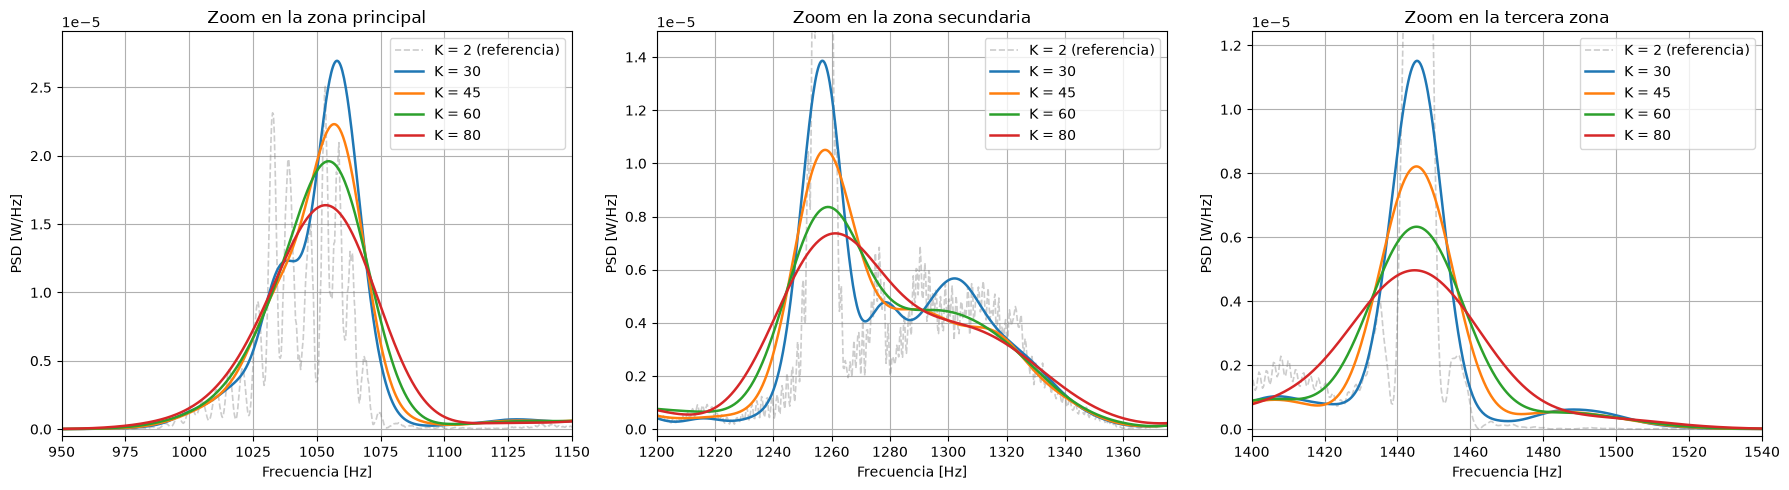

Límite inferior = 1012.67 Hz
Límite superior = 1959.00 Hz
Ancho de banda al 95% = 946.33 Hz


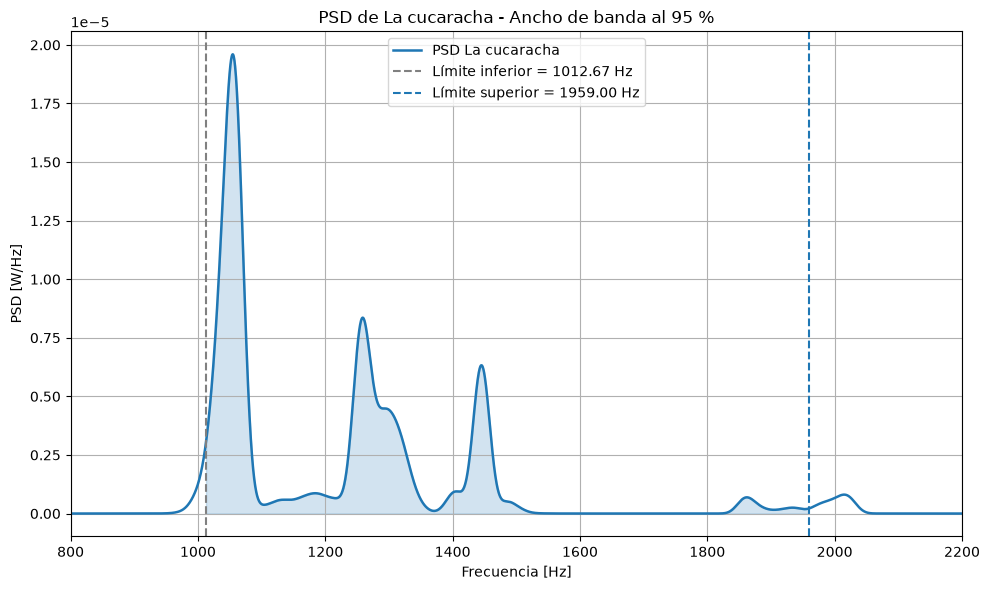

In [57]:
# LA CUCARACHA
fs_audio1, wav_data1 = sio.wavfile.read('la cucaracha.wav')
N_audio1 = len(wav_data1)

# señal en el tiempo
t_audio1 = np.arange(N_audio1) / fs_audio1

plt.figure(figsize=(10,3))
plt.plot(t_audio1, wav_data1)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('La cucaracha - Dominio del tiempo')
plt.grid()
plt.tight_layout()
plt.show()

# comparo distintos valores de K
K_ref = 2
K_vec = [30, 45, 60, 80]

L_ref = N_audio1 // K_ref
overlap_ref = L_ref // 2
f_ref, pxx_ref = sig.welch(wav_data1, fs=fs_audio1, window='hann', nperseg=L_ref, noverlap=overlap_ref, nfft=N_audio1, scaling='density')

curvas = {}
for K in K_vec:
    L = N_audio1 // K
    overlap = L // 2
    f, pxx = sig.welch(wav_data1, fs=fs_audio1, window='hann', nperseg=L, noverlap=overlap, nfft=N_audio1, scaling='density')
    curvas[K] = (f, pxx)

# PSD general
plt.figure(figsize=(10,6))
plt.plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')

for K in K_vec:
    f, pxx = curvas[K]
    plt.plot(f, pxx, linewidth=1.8, label=f'K = {K}')

plt.xlim([900,2100])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD del audio - La cucaracha')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# zooms
r1 = (950,1150)
r2 = (1200,1375)
r3 = (1400,1540)

max1 = 0
max2 = 0
max3 = 0

for K in K_vec:
    f, pxx = curvas[K]
    max1 = max(max1, np.max(pxx[(f >= r1[0]) & (f <= r1[1])]))
    max2 = max(max2, np.max(pxx[(f >= r2[0]) & (f <= r2[1])]))
    max3 = max(max3, np.max(pxx[(f >= r3[0]) & (f <= r3[1])]))

fig, ax = plt.subplots(1,3,figsize=(18,5))

for a in ax:
    a.plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')
    for K in K_vec:
        f, pxx = curvas[K]
        a.plot(f, pxx, linewidth=1.8, label=f'K = {K}')
    a.set_xlabel('Frecuencia [Hz]')
    a.set_ylabel('PSD [W/Hz]')
    a.grid()
    a.legend()

ax[0].set_xlim(r1)
ax[0].set_ylim([-0.02*max1,1.08*max1])
ax[0].set_title('Zoom en la zona principal')

ax[1].set_xlim(r2)
ax[1].set_ylim([-0.02*max2,1.08*max2])
ax[1].set_title('Zoom en la zona secundaria')

ax[2].set_xlim(r3)
ax[2].set_ylim([-0.02*max3,1.08*max3])
ax[2].set_title('Zoom en la tercera zona')

plt.tight_layout()
plt.show()

# PSD final con K=60
K_audio1 = 60
L_audio1 = N_audio1 // K_audio1
overlap_audio1 = L_audio1 // 2
f_audio1, pxx_audio1 = sig.welch(wav_data1, fs=fs_audio1, window='hann', nperseg=L_audio1, noverlap=overlap_audio1, nfft=N_audio1, scaling='density')

df = f_audio1[1] - f_audio1[0]

# potencia total
potencia_total = 0
for i in range(1, len(f_audio1)):
    area = (pxx_audio1[i-1] + pxx_audio1[i]) / 2 * df
    potencia_total += area

# limites que dejan 2.5% de potencia a cada lado
potencia_acumulada = 0
f_inf = 0
f_sup = 0

for i in range(1, len(f_audio1)):
    area = (pxx_audio1[i-1] + pxx_audio1[i]) / 2 * df
    potencia_acumulada += area

    if potencia_acumulada >= 0.025*potencia_total and f_inf == 0:
        f_inf = f_audio1[i]

    if potencia_acumulada >= 0.975*potencia_total:
        f_sup = f_audio1[i]
        break

BW_audio1 = f_sup - f_inf

print(f'Límite inferior = {f_inf:.2f} Hz')
print(f'Límite superior = {f_sup:.2f} Hz')
print(f'Ancho de banda al 95% = {BW_audio1:.2f} Hz')

plt.figure(figsize=(10,6))
plt.plot(f_audio1, pxx_audio1, linewidth=1.8, label='PSD La cucaracha')
plt.axvline(f_inf, linestyle='--', color='gray', label=f'Límite inferior = {f_inf:.2f} Hz')
plt.axvline(f_sup, linestyle='--', color='tab:blue', label=f'Límite superior = {f_sup:.2f} Hz')
plt.fill_between(f_audio1, 0, pxx_audio1, where=(f_audio1 >= f_inf) & (f_audio1 <= f_sup), alpha=0.2, color='tab:blue')
plt.xlim([800,2200])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD de La cucaracha - Ancho de banda al 95 %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### Elección de K

Tal como se observa en la figura general, la PSD presenta tres regiones principales con una contribución importante a la potencia de la señal. También se distingue una cuarta región aproximadamente entre 1800 y 2000 Hz, aunque su contribución es considerablemente menor respecto de las tres anteriores, por lo que no se tomó como zona principal para la elección de $K$.

Se compararon los valores $K=30$, $45$, $60$ y $80$. Para $K=30$ se obtiene una resolución mayor a la necesaria para este análisis, mientras que para $K=80$ se observa un suavizado excesivo y un mayor ensanchamiento de los lóbulos, indicando una pérdida apreciable de resolución espectral.

Por este motivo, la elección se concentró entre $K=45$ y $K=60$. Como se observa en las figuras ampliadas, ambos valores conservan adecuadamente las estructuras espectrales relevantes y no presentan grandes diferencias de resolución. Con $K=45$ se obtienen aproximadamente $M=89$ segmentos, mientras que con $K=60$ se obtienen $M=119$. Considerando que la varianza disminuye aproximadamente de forma inversa con la cantidad de promedios:
$
\frac{\mathrm{var}_{60}}{\mathrm{var}_{45}}\approx\frac{89}{119}=0.75
$

el uso de $K=60$ representa una reducción aproximada del $25\,\%$ en la varianza respecto de $K=45$. Dado que esta reducción se obtiene sin una pérdida visualmente significativa de la resolución en las zonas de interés, se seleccionó $K=60$.

#### Ancho de banda de "La Cucaracha"

Como la PSD de este audio presenta un comportamiento pasa-banda, los límites se determinaron utilizando el criterio definido anteriormente. El límite inferior se ubicó en la frecuencia a partir de la cual queda acumulado el 2.5 % de la potencia total, mientras que el límite superior se determinó dejando un 2.5 % de la potencia por encima de él. De esta manera, el intervalo comprendido entre ambos límites contiene el 95 % de la potencia de la señal.Se obtuvo un ancho de banda estimado de $BW=947.33$ Hz.

#### Prueba PSD

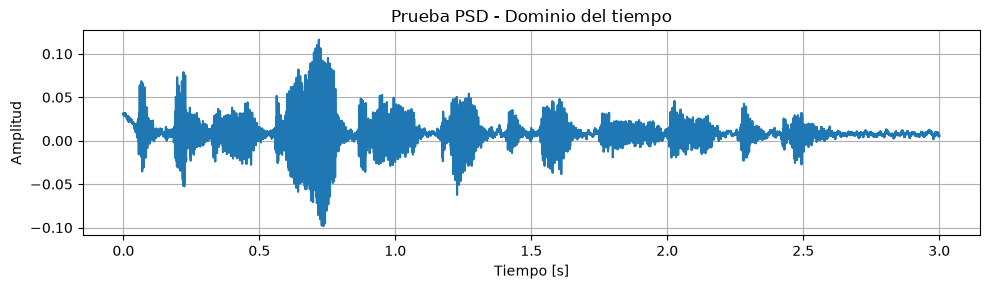

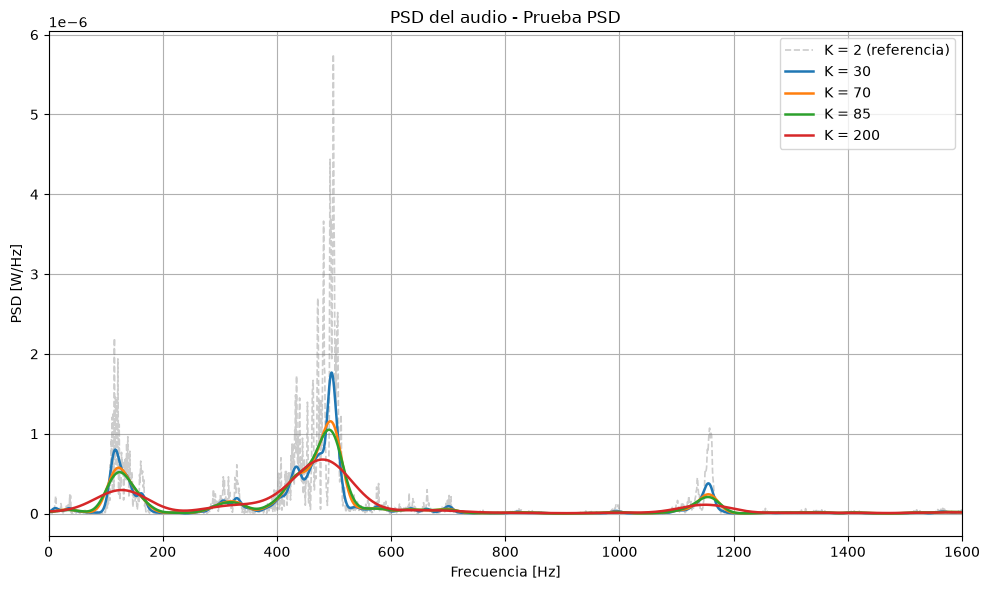

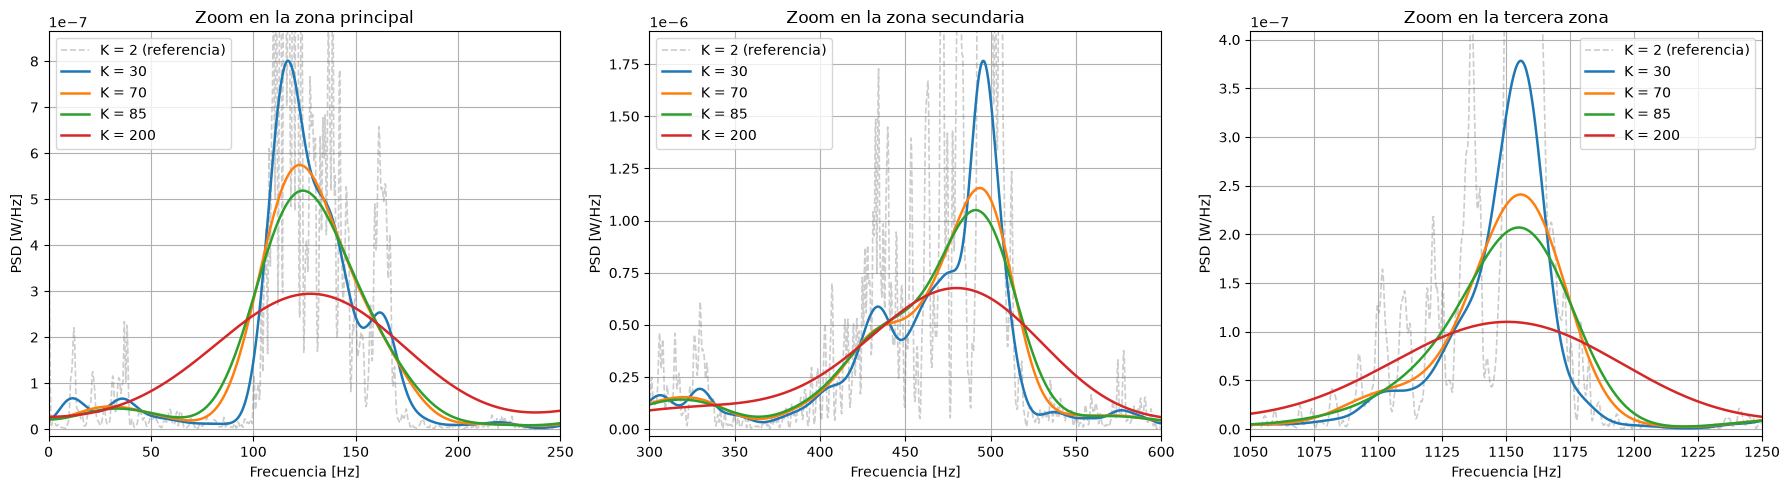

Ancho de banda al 95% = 1187.00 Hz


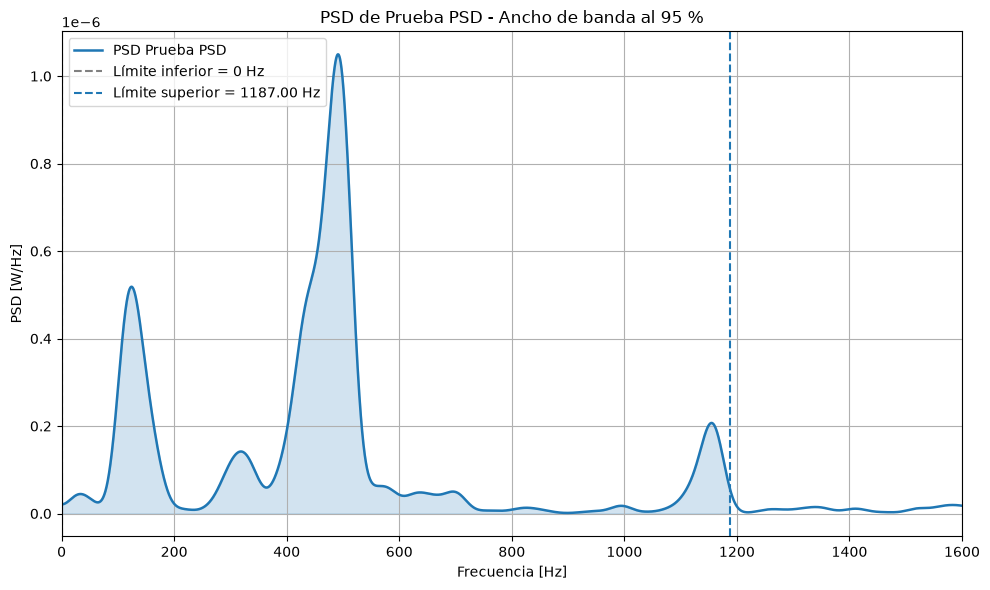

In [53]:
# PRUEBA PSD
fs_audio2, wav_data2 = sio.wavfile.read('prueba psd.wav')
N_audio2 = len(wav_data2)

# señal en el tiempo
t_audio2 = np.arange(N_audio2) / fs_audio2

plt.figure(figsize=(10,3))
plt.plot(t_audio2, wav_data2)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Prueba PSD - Dominio del tiempo')
plt.grid()
plt.tight_layout()
plt.show()

# comparo distintos valores de K
K_ref = 2
K_vec = [30, 70, 85, 200]

L_ref = N_audio2 // K_ref
overlap_ref = L_ref // 2
f_ref, pxx_ref = sig.welch(wav_data2, fs=fs_audio2, window='hann', nperseg=L_ref, noverlap=overlap_ref, nfft=N_audio2, scaling='density')

curvas = {}
for K in K_vec:
    L = N_audio2 // K
    overlap = L // 2
    f, pxx = sig.welch(wav_data2, fs=fs_audio2, window='hann', nperseg=L, noverlap=overlap, nfft=N_audio2, scaling='density')
    curvas[K] = (f, pxx)

# PSD general
plt.figure(figsize=(10,6))
plt.plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')

for K in K_vec:
    f, pxx = curvas[K]
    plt.plot(f, pxx, linewidth=1.8, label=f'K = {K}')

plt.xlim([0,1600])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD del audio - Prueba PSD')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# zooms
r1 = (0,250)
r2 = (300,600)
r3 = (1050,1250)

max1 = 0
max2 = 0
max3 = 0

for K in K_vec:
    f, pxx = curvas[K]
    max1 = max(max1, np.max(pxx[(f >= r1[0]) & (f <= r1[1])]))
    max2 = max(max2, np.max(pxx[(f >= r2[0]) & (f <= r2[1])]))
    max3 = max(max3, np.max(pxx[(f >= r3[0]) & (f <= r3[1])]))

fig, ax = plt.subplots(1,3,figsize=(18,5))

for a in ax:
    a.plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')
    for K in K_vec:
        f, pxx = curvas[K]
        a.plot(f, pxx, linewidth=1.8, label=f'K = {K}')
    a.set_xlabel('Frecuencia [Hz]')
    a.set_ylabel('PSD [W/Hz]')
    a.grid()
    a.legend()

ax[0].set_xlim(r1)
ax[0].set_ylim([-0.02*max1,1.08*max1])
ax[0].set_title('Zoom en la zona principal')

ax[1].set_xlim(r2)
ax[1].set_ylim([-0.02*max2,1.08*max2])
ax[1].set_title('Zoom en la zona secundaria')

ax[2].set_xlim(r3)
ax[2].set_ylim([-0.02*max3,1.08*max3])
ax[2].set_title('Zoom en la tercera zona')

plt.tight_layout()
plt.show()

# PSD final con K=85
K_audio2 = 85
L_audio2 = N_audio2 // K_audio2
overlap_audio2 = L_audio2 // 2
f_audio2, pxx_audio2 = sig.welch(wav_data2, fs=fs_audio2, window='hann', nperseg=L_audio2, noverlap=overlap_audio2, nfft=N_audio2, scaling='density')

df = f_audio2[1] - f_audio2[0]

# potencia total
potencia_total = 0
for i in range(1, len(f_audio2)):
    area = (pxx_audio2[i-1] + pxx_audio2[i]) / 2 * df
    potencia_total += area

# frecuencia que acumula el 95% de la potencia
potencia_95 = 0.95 * potencia_total
potencia_acumulada = 0

for i in range(1, len(f_audio2)):
    area = (pxx_audio2[i-1] + pxx_audio2[i]) / 2 * df
    potencia_acumulada += area
    if potencia_acumulada >= potencia_95:
        f_95 = f_audio2[i]
        break

print(f'Ancho de banda al 95% = {f_95:.2f} Hz')

plt.figure(figsize=(10,6))
plt.plot(f_audio2, pxx_audio2, linewidth=1.8, label='PSD Prueba PSD')
plt.axvline(0, linestyle='--', color='gray', label='Límite inferior = 0 Hz')
plt.axvline(f_95, linestyle='--', color='tab:blue', label=f'Límite superior = {f_95:.2f} Hz')
plt.fill_between(f_audio2, 0, pxx_audio2, where=(f_audio2 >= 0) & (f_audio2 <= f_95), alpha=0.2, color='tab:blue')
plt.xlim([0,1600])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD de Prueba PSD - Ancho de banda al 95 %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### Elección de K

Tal como se observa en la figura general, la PSD presenta tres zonas principales en las que se concentra la mayor parte de la potencia de la señal. A partir de estas regiones se analizaron con mayor detalle los cambios producidos al variar el valor de $K$.

Se compararon los valores $K=30$, $70$, $85$ y $200$. Para $K=30$ se obtiene una resolución mayor a la necesaria para este análisis, mientras que con $K=200$ se observa un suavizado excesivo y un ensanchamiento importante de las estructuras espectrales, por lo que este valor no se consideró adecuado.

La elección se concentró entonces entre $K=70$ y $K=85$. Como se observa en las figuras ampliadas, ambos valores representan de manera muy similar los picos y las estructuras relevantes de las tres zonas analizadas. Sin embargo, $K=85$ permite realizar una mayor cantidad de promedios y, por lo tanto, obtener una menor varianza del estimador, sin producir una pérdida apreciable de resolución. Por este motivo se seleccionó $K=85$.

#### Ancho de banda de "Prueba PSD"

Si bien este audio no presenta estrictamente un comportamiento pasa-bajos, se observa que posee contenido espectral relevante desde frecuencias cercanas a $0$ Hz. Por este motivo, para la estimación del ancho de banda se tomó $0$ Hz como límite inferior y se buscó la frecuencia hasta la cual se acumula el 95 % de la potencia total.

De esta manera, el ancho de banda estimado queda $BW=1187$ Hz.

#### SILBIDO

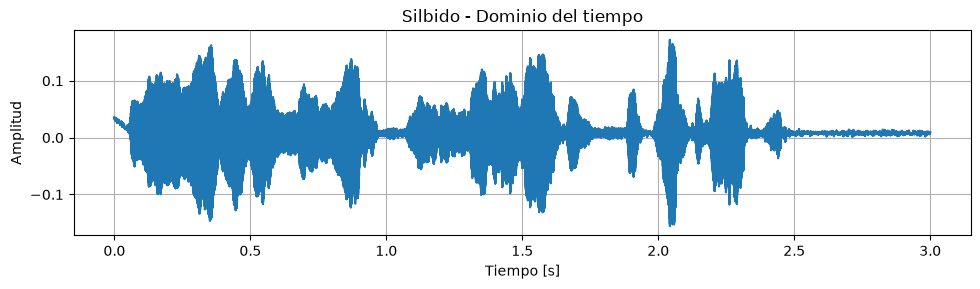

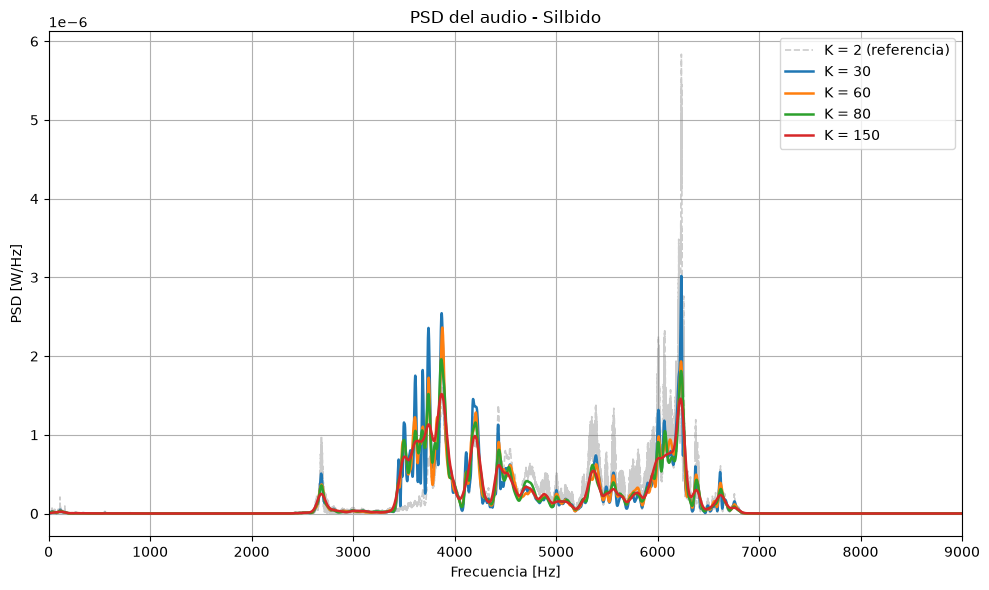

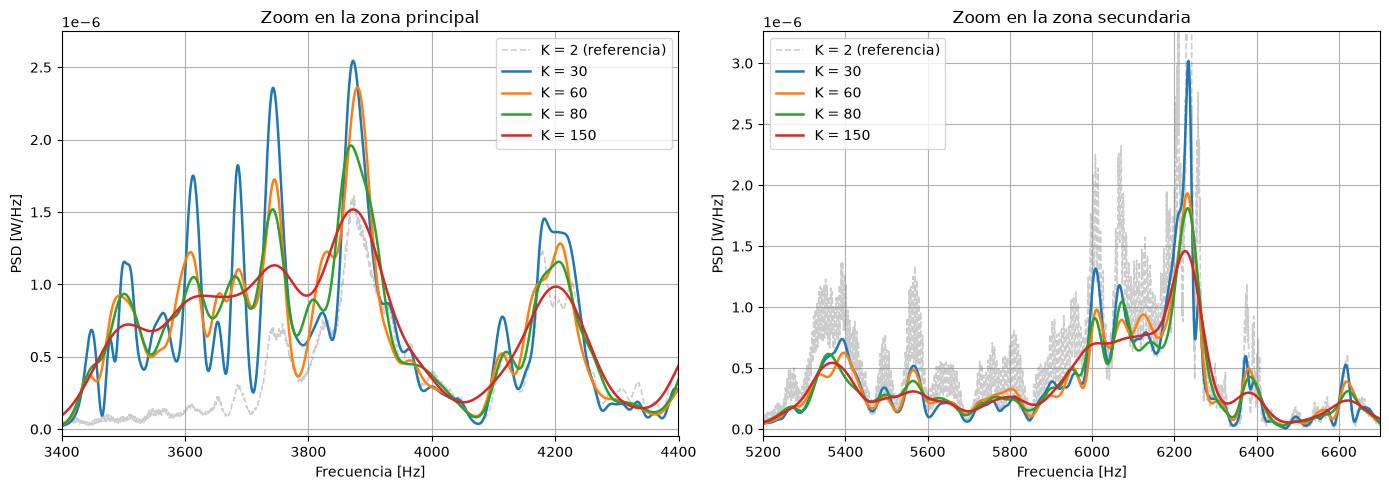

Límite inferior = 2944.67 Hz
Límite superior = 6503.67 Hz
Ancho de banda al 95% = 3559.00 Hz


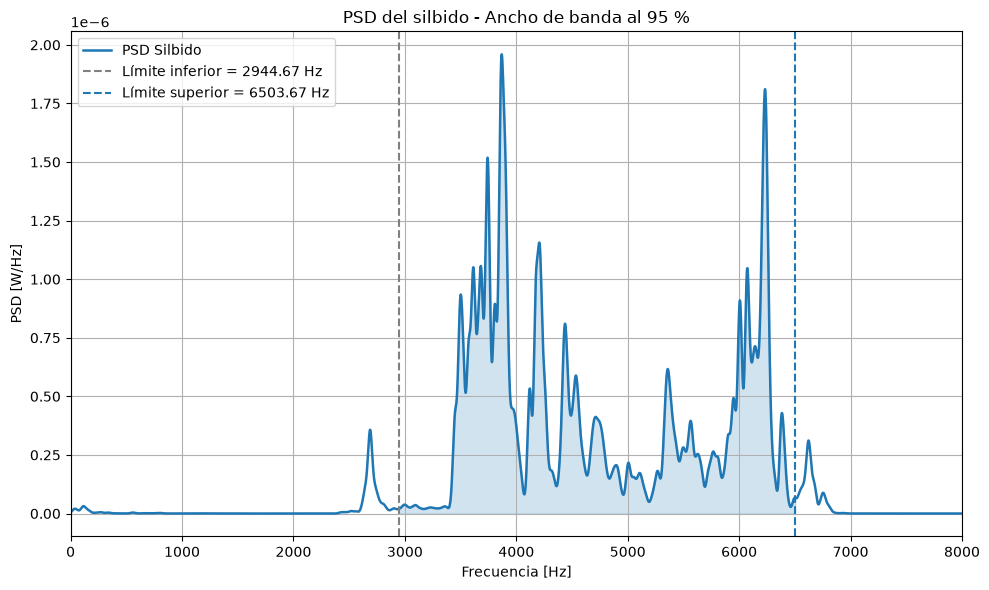

In [54]:
# SILBIDO
fs_audio3, wav_data3 = sio.wavfile.read('silbido.wav')
N_audio3 = len(wav_data3)

# señal en el tiempo
t_audio3 = np.arange(N_audio3) / fs_audio3

plt.figure(figsize=(10,3))
plt.plot(t_audio3, wav_data3)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Silbido - Dominio del tiempo')
plt.grid()
plt.tight_layout()
plt.show()

# comparo distintos valores de K
K_ref = 2
K_vec = [30, 60, 80, 150]

L_ref = N_audio3 // K_ref
overlap_ref = L_ref // 2
f_ref, pxx_ref = sig.welch(wav_data3, fs=fs_audio3, window='hann', nperseg=L_ref, noverlap=overlap_ref, nfft=N_audio3, scaling='density')

curvas = {}
for K in K_vec:
    L = N_audio3 // K
    overlap = L // 2
    f, pxx = sig.welch(wav_data3, fs=fs_audio3, window='hann', nperseg=L, noverlap=overlap, nfft=N_audio3, scaling='density')
    curvas[K] = (f, pxx)

# PSD general
plt.figure(figsize=(10,6))
plt.plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')

for K in K_vec:
    f, pxx = curvas[K]
    plt.plot(f, pxx, linewidth=1.8, label=f'K = {K}')

plt.xlim([0,9000])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD del audio - Silbido')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# zooms
r1 = (3400,4400)
r2 = (5200,6700)

max1 = 0
max2 = 0

for K in K_vec:
    f, pxx = curvas[K]
    max1 = max(max1, np.max(pxx[(f >= r1[0]) & (f <= r1[1])]))
    max2 = max(max2, np.max(pxx[(f >= r2[0]) & (f <= r2[1])]))

fig, ax = plt.subplots(1,2,figsize=(14,5))

for a in ax:
    a.plot(f_ref, pxx_ref, '--', linewidth=1.2, alpha=0.4, color='gray', label='K = 2 (referencia)')
    for K in K_vec:
        f, pxx = curvas[K]
        a.plot(f, pxx, linewidth=1.8, label=f'K = {K}')
    a.set_xlabel('Frecuencia [Hz]')
    a.set_ylabel('PSD [W/Hz]')
    a.grid()
    a.legend()

ax[0].set_xlim(r1)
ax[0].set_ylim([-0.02*max1,1.08*max1])
ax[0].set_title('Zoom en la zona principal')

ax[1].set_xlim(r2)
ax[1].set_ylim([-0.02*max2,1.08*max2])
ax[1].set_title('Zoom en la zona secundaria')

plt.tight_layout()
plt.show()

# PSD final con K=80
K_audio3 = 80
L_audio3 = N_audio3 // K_audio3
overlap_audio3 = L_audio3 // 2
f_audio3, pxx_audio3 = sig.welch(wav_data3, fs=fs_audio3, window='hann', nperseg=L_audio3, noverlap=overlap_audio3, nfft=N_audio3, scaling='density')

df = f_audio3[1] - f_audio3[0]

# potencia total
potencia_total = 0
for i in range(1, len(f_audio3)):
    area = (pxx_audio3[i-1] + pxx_audio3[i]) / 2 * df
    potencia_total += area

# limites que dejan 2.5% de potencia a cada lado
potencia_acumulada = 0
f_inf = 0
f_sup = 0

for i in range(1, len(f_audio3)):
    area = (pxx_audio3[i-1] + pxx_audio3[i]) / 2 * df
    potencia_acumulada += area

    if potencia_acumulada >= 0.025*potencia_total and f_inf == 0:
        f_inf = f_audio3[i]

    if potencia_acumulada >= 0.975*potencia_total:
        f_sup = f_audio3[i]
        break

BW_audio3 = f_sup - f_inf

print(f'Límite inferior = {f_inf:.2f} Hz')
print(f'Límite superior = {f_sup:.2f} Hz')
print(f'Ancho de banda al 95% = {BW_audio3:.2f} Hz')

plt.figure(figsize=(10,6))
plt.plot(f_audio3, pxx_audio3, linewidth=1.8, label='PSD Silbido')
plt.axvline(f_inf, linestyle='--', color='gray', label=f'Límite inferior = {f_inf:.2f} Hz')
plt.axvline(f_sup, linestyle='--', color='tab:blue', label=f'Límite superior = {f_sup:.2f} Hz')
plt.fill_between(f_audio3, 0, pxx_audio3, where=(f_audio3 >= f_inf) & (f_audio3 <= f_sup), alpha=0.2, color='tab:blue')
plt.xlim([0,8000])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [W/Hz]')
plt.title('PSD del silbido - Ancho de banda al 95 %')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

#### Elección de K

Tal como se observa en las figuras, se compararon los valores $K=30$, $60$, $80$ y $150$. Para $K=30$ se obtiene una elevada resolución espectral, aunque parte de esa resolución corresponde a pequeñas variaciones que no resultan relevantes para caracterizar la estructura general de la señal.

Al aumentar a $K=60$ y $K=80$, los principales picos y regiones de interés continúan siendo representados adecuadamente, mientras que las variaciones de menor importancia se suavizan. En cambio, para $K=150$ se observa un ensanchamiento y suavizado mucho más marcado de los picos, indicando una pérdida apreciable de resolución.

Por este motivo, la elección se concentró entre $K=60$ y $K=80$. Con $K=60$ se obtienen aproximadamente $M=119$ segmentos, mientras que con $K=80$ se obtienen $M=159$. Considerando que la varianza disminuye aproximadamente de forma inversa con la cantidad de promedios:
$
\frac{\mathrm{var}_{80}}{\mathrm{var}_{60}}
\approx
\frac{119}{159}
\approx0.75
$

el uso de $K=80$ representa una reducción aproximada del $25\,\%$ en la varianza respecto de $K=60$. Como en las figuras ampliadas no se observa una pérdida significativa de los picos principales, se seleccionó $K=80$ como compromiso entre resolución espectral y varianza.

#### Ancho de banda del "Silbido"

Como la PSD presenta un comportamiento pasa-banda, se utilizó el criterio definido anteriormente, dejando un 2.5 % de la potencia total a cada extremo. Se obtuvo un límite inferior de $f_{inf}=2944.67$ Hz y un límite superior de $f_{sup}=6503.67$ Hz, resultando en un ancho de banda estimado de $BW=3559$ Hz.

### Comparación de los anchos de banda

A partir de los criterios definidos anteriormente, se obtuvieron los siguientes anchos de banda para las cinco señales analizadas:

| Señal | $K$ seleccionado | $f_{inf}$ [Hz] | $f_{sup}$ [Hz] | $BW$ [Hz] |
|---|---:|---:|---:|---:|
| ECG | 35 | 0.00 | 22.83 | 22.83 |
| PPG | 45 | 0.00 | 3.95 | 3.95 |
| La Cucaracha | 60 | 1012.67 | 1959.00 | 946.33 |
| Prueba PSD | 85 | 0.00 | 1187.00 | 1187.00 |
| Silbido | 80 | 2944.67 | 6503.67 | 3559.00 |

A partir de los resultados obtenidos se observa que las señales fisiológicas presentan anchos de banda considerablemente menores que las señales de audio. El PPG presenta el menor ancho de banda, con $3.95$ Hz, seguido por el ECG con $22.83$ Hz. En cambio, las señales de audio presentan una distribución de potencia sobre intervalos de frecuencia mucho más amplios, obteniéndose $946.33$ Hz para "La Cucaracha", $1187.00$ Hz para "Prueba PSD" y $3559.00$ Hz para el "Silbido".

Un mayor ancho de banda indica que el intervalo de frecuencias necesario para contener el 95 % de la potencia de la señal es más amplio. Por lo tanto, la señal presenta contenido significativo distribuido sobre un rango mayor de frecuencias. Esto se observa especialmente en las señales de audio, mientras que en el ECG y el PPG la potencia se encuentra mucho más concentrada en bajas frecuencias.

<div style="background-color:#d9f2ff; padding:6px 10px; border-radius:6px;">
<h2 style="margin:0;">Conclusiones</h2>
</div>

Este trabajo me permitió aplicar de manera práctica el método de Welch para estimar la densidad espectral de potencia de distintas señales y comprender mejor el compromiso entre resolución espectral y varianza del estimador.

La comparación entre el periodograma y Welch también me permitió profundizar mi comprensión de los estimadores espectrales. Pude observar que, si bien el periodograma presenta una mayor resolución, su estimación tiene una mayor variabilidad, mientras que Welch permite reducir la varianza mediante el promedio de distintos segmentos de la señal. Si bien Blackman-Tukey constituye otra alternativa válida para la estimación de la PSD, para este desarrollo se optó por utilizar Welch.

A partir de la comparación entre distintos valores de $K$, pude establecer un criterio de selección basado en conservar las estructuras espectrales relevantes de cada señal, evitando tanto una resolución innecesariamente alta como un suavizado excesivo.

También profundicé mi comprensión del concepto de ancho de banda y adopté un criterio objetivo para estimarlo a partir del intervalo que contiene el 95 % de la potencia de la señal, diferenciando el procedimiento según se tratara de señales con comportamiento pasa-bajos o pasa-banda.

En general, el trabajo me permitió mejorar mi entendimiento sobre los estimadores espectrales y adquirir un criterio más sólido para analizar e interpretar señales reales en el dominio de la frecuencia.